# Plotting Correlations by Region on a Global Map

### Importing Packages

In [3]:
!pip install cartopy

import xarray as xr
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle
from matplotlib import cm, colors
import matplotlib.patheffects as patheffects
import numpy as np
from scipy.stats import pearsonr
import warnings

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 78.3 MB/s eta 0:00:00


### Opening Datasets

In [4]:
nh_ds = xr.open_dataset("NH_tele_cli_anoms_detrended_1950-2024.nc")
sh_ds = xr.open_dataset("SH_tele_cli_anoms_detrended_1950-2024.nc")
global_ds = xr.open_dataset("Global_tele_cli_anoms_detrended_1950-2024.nc")
nh_ds

<xarray.Dataset> Size: 497kB
Dimensions:                                  (year: 75, month: 12)
Coordinates:
  * year                                     (year) int64 600B 1950 ... 2024
  * month                                    (month) int64 96B 1 2 3 ... 11 12
    time                                     (year, month) datetime64[ns] 7kB ...
Data variables: (12/68)
    TNA                                      (year, month) float64 7kB ...
    WPO                                      (year, month) float64 7kB ...
    WP                                       (year, month) float64 7kB ...
    SCA                                      (year, month) float64 7kB ...
    EAWR                                     (year, month) float64 7kB ...
    EA                                       (year, month) float64 7kB ...
    ...                                       ...
    TP_Anomaly_Western_Australia_Detrended   (year, month) float64 7kB ...
    TP_StdAnom_Western_Australia_Detrended   (year, month) float64 7kB ...
    T2M_Anomaly_Northeast_Detrended          (year, month) float64 7kB ...
    T2M_StdAnom_Northeast_Detrended          (year, month) float64 7kB ...
    TP_Anomaly_Northeast_Detrended           (year, month) float64 7kB ...
    TP_StdAnom_Northeast_Detrended           (year, month) float64 7kB ...
Attributes:
    Name:                   NH Teleconnections and Regional Climate Anomalies...
    Teleconnection_source:  Climate Prediction Center
    Anomaly_source:         ECMWF Reanalysis v5 (ERA5)

### Computing and Plotting Correlations

In [ ]:
warnings.filterwarnings("ignore")

month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
               7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}

dataset_options = {'Northern Hemisphere': nh_ds, 'Southern Hemisphere': sh_ds, 'Global': global_ds}

index_map = {'Northern Hemisphere': ['TNA', 'WPO', 'WP', 'SCA', 'EAWR', 'EA', 'ADI', 'AMO',
                                     'AO', 'EPNP', 'EPO', 'NAO', 'NOI', 'PDO', 'PNA', 'POL'],
             'Southern Hemisphere': ['SAOD', 'TSA', 'SPOD', 'TPI', 'SOI', 'AAO'],
             'Global': ['IPO', 'IOD', 'EMI', 'QBO', 'MEI', 'AAM', 'ENSO_34']}

regions = [[-98, -81, 37, 49, 'Midwest'],
           [-105, -93, 26, 41, 'Southern_Plains'],
           [-81, -67, 37, 48, 'Northeast'],
           [-9, 11, 36, 55, 'Western_Europe'],
           [11, 32, 36, 55, 'Eastern_Europe'],
           [32, 55, 38, 57, 'Black_Sea'],
           [65, 90, 5, 33, 'India'],
           [105, 130, 20, 45, 'East_Asia'],
           [111, 135, -36, -12, 'Western_Australia'],
           [135, 155, -40, -14, 'Eastern_Australia'],
           [-60, -35, -15, 0, 'Northern_Brazil'],
           [-60, -35, -30, -15, 'Southern_Brazil'],
           [-69, -55, -22, -42, 'Argentina']]

month_options = [('All Months', None)] + [(f"{month_names[m]}", m) for m in range(1, 13)]

def get_variable_name(base_var, region_name):
    return f"{base_var}_StdAnom_{region_name.replace(' ', '_')}_Detrended"

def compute_and_plot(dataset_name, index_name, month, variable_type):
    with output:
        clear_output(wait=True)

        ds = dataset_options[dataset_name]
        base_var = 'T2M' if variable_type == 'Std Temp Anomaly' else 'TP'

        title_month = "All Months" if month is None else month_names[month]
        data_full = ds if month is None else ds.where(ds.time.dt.month == month, drop=True)

        correlations = []

        region_names = [r[4] for r in regions]
        for region_name in region_names:
            var_name = get_variable_name(base_var, region_name)
            data_da = data_full[var_name]
            d = data_da.values
            i = ds[index_name].values
            dt = data_da.time.values
            it = ds[index_name].time.values
            m1 = np.isin(dt, it)
            m2 = np.isin(it, dt[m1])
            x = d[m1]
            y = i[m2]
            v = ~(np.isnan(x) | np.isnan(y))
            r = pearsonr(x[v], y[v])[0] if v.sum() >= 5 and m1.sum() >= 5 else 0.0
            correlations.append(abs(r))

        max_abs = max(correlations) if correlations else 0.3
        norm = colors.Normalize(vmin=-max_abs, vmax=max_abs)

        fig, ax = plt.subplots(figsize=(10, 8), dpi=400, subplot_kw={'projection': ccrs.PlateCarree()})

        title_var = "Temperature" if variable_type == 'Std Temp Anomaly' else "Precipitation"
        ax.set_title(f'{index_name} Correlation with {title_var} ({title_month})', fontsize=14, fontweight='bold')

        cmap = plt.colormaps['seismic'] if variable_type == 'Std Temp Anomaly' else plt.colormaps['BrBG']

        for lon_min, lon_max, lat_min, lat_max, region_name in regions:
            var_name = get_variable_name(base_var, region_name)
            data_da = data_full[var_name]
            d = data_da.values
            i = ds[index_name].values
            dt = data_da.time.values
            it = ds[index_name].time.values
            m1 = np.isin(dt, it)
            m2 = np.isin(it, dt[m1])
            x = d[m1]
            y = i[m2]
            v = ~(np.isnan(x) | np.isnan(y))
            region_corr = pearsonr(x[v], y[v])[0] if v.sum() >= 5 and m1.sum() >= 5 else 0.0

            color = cmap(norm(region_corr))
            rect = Rectangle(xy=(lon_min, lat_min), width=lon_max-lon_min, height=lat_max-lat_min,
                             facecolor=color, edgecolor='black', linewidth=1.8, alpha=1,
                             transform=ccrs.PlateCarree(), zorder=2)
            ax.add_patch(rect)

            cx = (lon_min + lon_max) / 2
            cy = (lat_min + lat_max) / 2
            ax.text(cx, cy, f"{region_corr:.2f}", transform=ccrs.PlateCarree(),
                    ha='center', va='center', fontsize=8, fontweight='bold', color='white',
                    zorder=3, path_effects=[patheffects.withStroke(linewidth=1.5, foreground='black')])

        ax.add_feature(cfeature.COASTLINE, lw=0.7, color='dimgray', zorder=2)
        ax.add_feature(cfeature.LAND, facecolor='#f0f0e8', zorder=0)
        ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)

        gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.4, color="gray", alpha=0.7, zorder=1)
        gl.top_labels = False
        gl.right_labels = False
        ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.01, shrink=0.506, aspect=20)
        cbar.set_label(f'Correlation with {title_var}', fontsize=11)

        plt.tight_layout()
        display(fig)
        plt.close(fig)

        var_short = "Temp" if variable_type == 'Std Temp Anomaly' else "Precip"
        filename = f"{index_name}_{title_month.replace(' ', '_')}_{var_short}_Correlation.png"
        fig.savefig(filename, dpi=400, bbox_inches='tight')

dataset_widget = widgets.Dropdown(options=list(dataset_options.keys()), value='Global', description='Dataset:')
index_widget = widgets.Dropdown(options=index_map['Global'], description='Teleconnection:')

def update_index_options(change):
    index_widget.options = index_map[change['new']]

dataset_widget.observe(update_index_options, names='value')

month_widget = widgets.Dropdown(options=month_options, value=None, description='Month:')
variable_widget = widgets.Dropdown(options=['Std Temp Anomaly', 'Std Precip Anomaly'],
                                   value='Std Temp Anomaly', description='Variable:')

button = widgets.Button(description="Compute & Plot Correlation Map", button_style='success', layout=widgets.Layout(width='220px'))
output = widgets.Output()

def on_button_clicked(b):
    compute_and_plot(dataset_widget.value, index_widget.value, month_widget.value, variable_widget.value)

button.on_click(on_button_clicked)

display(widgets.VBox([dataset_widget, index_widget, month_widget, variable_widget, button, output]))

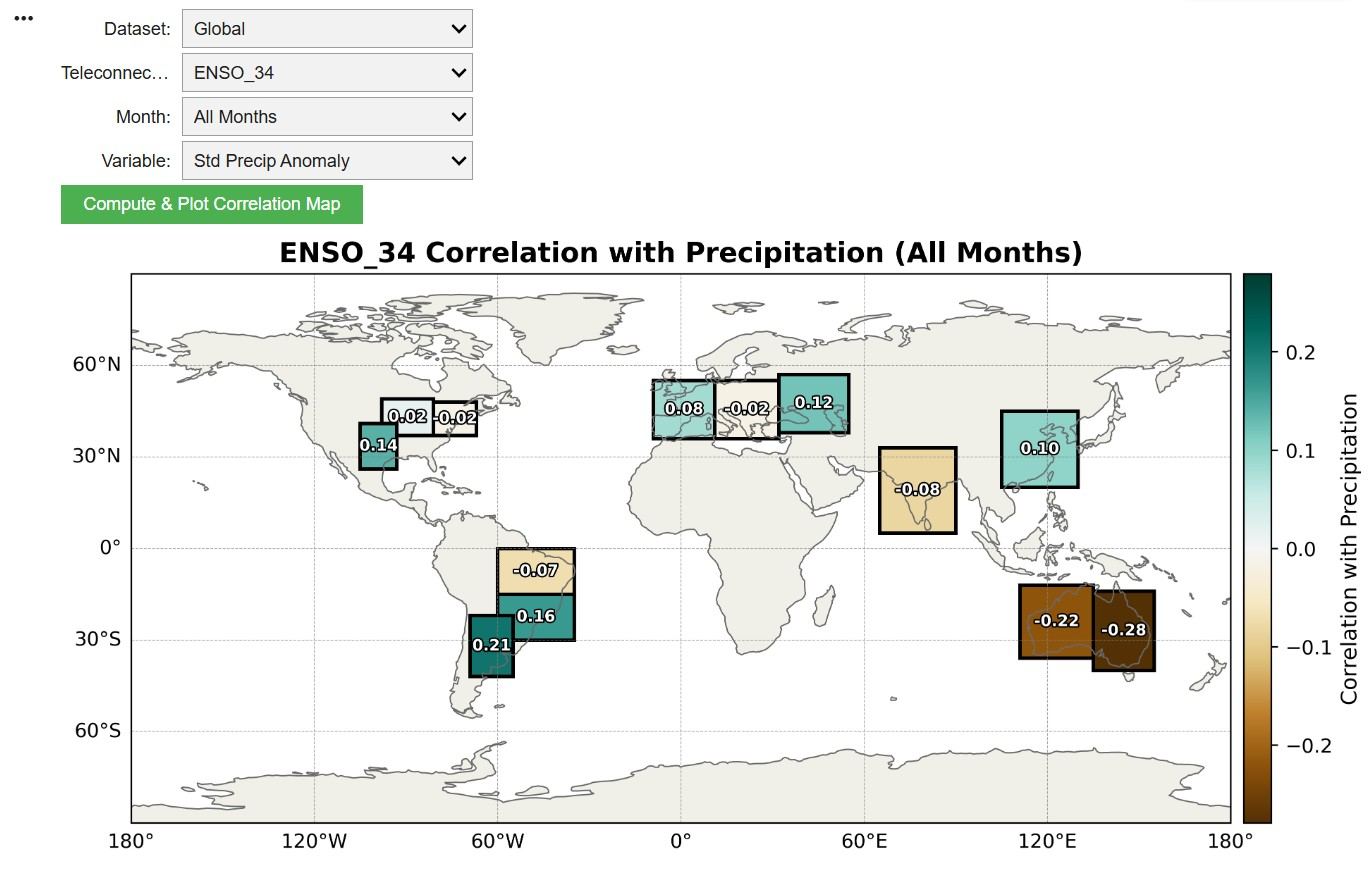